# MWE 09 - Simplified 2D image-based vug sensitivity

This notebook is a simplified 2D analogue of `08_mwe_image_based_vug_shape_sensitivity`.

Workflow:

- Generate connected 2D matrices using a selectable baseline generator
  (`voronoi_edges`, `blobs`, or both in compare mode).
- Insert one vug per case (circular or elliptical).
- Convert to synthetic grayscale, segment, extract pore network (`snow2` via `voids`).
- Solve single-phase flow and compare porosity and `K/K0`.
- Export Plotly pore-network visualizations for all solved cases.

Families included:

- circular vugs
- ellipses stretched in the flow direction
- ellipses stretched orthogonal to flow

Caveats:

- This remains a synthetic digital-rock proxy, not a direct experimental image.
- `snow2` extraction behavior can alter local connectivity around large vugs.
- Voronoi-edge pore space emphasizes grain-boundary-like channels in 2D.
- Blobs fallback to higher porosity if low-porosity percolation is not found.
- 2D trends may not transfer quantitatively to 3D.


In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    from tqdm.auto import tqdm as _tqdm
except Exception:  # pragma: no cover
    _tqdm = None

from voids.graph.metrics import coordination_numbers
from voids.physics.petrophysics import absolute_porosity, effective_porosity
from voids.physics.singlephase import (
    FluidSinglePhase,
    PressureBC,
    SinglePhaseOptions,
    solve,
)
from voids.visualization import plot_network_plotly
from voids.generators import (
    build_image_vug_radii_2d,
    equivalent_radius_2d,
    generate_spanning_matrix_2d,
    insert_circular_vug_2d,
    insert_elliptical_vug_2d,
    make_synthetic_grayscale_2d,
)
from voids.image import binarize_2d_with_voids, has_spanning_cluster_2d
from voids.image import extract_spanning_pore_network

/Users/dtvolpatto/Work/voids/.pixi/envs/lbm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def iter_progress(
    iterable,
    *,
    desc: str | None = None,
    total: int | None = None,
    enabled: bool = True,
    leave: bool = False,
):
    """Wrap iterables with tqdm when available and enabled."""

    if not enabled or _tqdm is None:
        return iterable
    return _tqdm(
        iterable,
        desc=desc,
        total=total,
        dynamic_ncols=True,
        leave=leave,
    )

In [3]:
# Study controls
VOXEL_SIZE_M = 10.0e-6
SHAPE_2D = (180, 180)
FLOW_AXIS = "x"
FLOW_AXIS_INDEX = {"x": 0, "y": 1}[FLOW_AXIS]

N_BASELINES = 6
TARGET_MATRIX_POROSITY = 0.18
BASE_SEED = 20260305
MAX_MATRIX_TRIES = 100

# Matrix generator controls.
#
# `compare` runs both generators with the same baseline ids and vug configs.
# `single` runs only `MATRIX_GENERATOR_SINGLE`.
MATRIX_GENERATOR_MODE = os.environ.get("VOIDS_MATRIX_GENERATOR_MODE", "compare")
MATRIX_GENERATOR_SINGLE = os.environ.get(
    "VOIDS_MATRIX_GENERATOR_SINGLE", "voronoi_edges"
)

# Baseline generators supported by this notebook:
# - voronoi_edges: naturally connected low-porosity edge network (void = ~matrix)
# - blobs: isotropic blobs; at low porosity this may not percolate in 2D, so
#   fallback porosity levels are tested with no artificial fracture/channel.
BLOBS_BLOBINESS = 1.8
BLOBS_FALLBACK_POROSITY_LEVELS = [0.22, 0.26, 0.30, 0.34, 0.38, 0.42, 0.45]

# Matrix generator controls for Voronoi mode.
VORONOI_EDGE_RADIUS_VOX = 0
VORONOI_TARGET_TOL = 0.003
VORONOI_NCELLS_STEP = 10
VORONOI_SEARCH_HALF_WINDOW = 70

# Five larger, centered 2D circular configurations.
CIRCLE_RADII_VOX = [12, 16, 20, 24, 28]

# Ellipse controls (area-matched to circular configs).
ELLIPSE_MATCH_ASPECT = 1.8  # major/minor ratio
ELLIPSE_INTEGER_SEARCH_WINDOW = 10

GRAYSCALE_VOID_MEAN = 70.0
GRAYSCALE_SOLID_MEAN = 185.0
GRAYSCALE_NOISE_STD = 8.0

PLOTLY_MAX_THROATS = 2000
PLOTLY_LAYOUT = {"width": 900, "height": 620}
PLOTLY_SIZE_LIMITS = (None, None)
USE_TQDM = os.environ.get("VOIDS_DISABLE_TQDM", "0") != "1"

# Fast mode for quick smoke checks
SMOKE_MODE = os.environ.get("VOIDS_VUG_SMOKE", "0") == "1"
if SMOKE_MODE:
    N_BASELINES = 2
    CIRCLE_RADII_VOX = CIRCLE_RADII_VOX[:2]

# Build ellipse configs area-matched to each circular config index.
(
    ELLIPSE_FLOW_RADII_VOX,
    ELLIPSE_ORTH_RADII_VOX,
    area_match_report,
) = build_image_vug_radii_2d(
    CIRCLE_RADII_VOX,
    aspect=ELLIPSE_MATCH_ASPECT,
    search_window=ELLIPSE_INTEGER_SEARCH_WINDOW,
)

if MATRIX_GENERATOR_MODE == "compare":
    MATRIX_GENERATORS = ["voronoi_edges", "blobs"]
elif MATRIX_GENERATOR_MODE == "single":
    MATRIX_GENERATORS = [MATRIX_GENERATOR_SINGLE]
else:
    raise ValueError(
        f"MATRIX_GENERATOR_MODE must be 'compare' or 'single', got: {MATRIX_GENERATOR_MODE}"
    )

MATRIX_GENERATORS = [str(g).strip().lower() for g in MATRIX_GENERATORS]
allowed_generators = {"voronoi_edges", "blobs"}
for generator_name in MATRIX_GENERATORS:
    if generator_name not in allowed_generators:
        raise ValueError(f"Unsupported generator '{generator_name}'")

print("shape_2d:", SHAPE_2D)
print("target matrix porosity:", TARGET_MATRIX_POROSITY)
print("voxel size:", VOXEL_SIZE_M, "m")
print("flow axis:", FLOW_AXIS)
print("baselines:", N_BASELINES)
print("matrix generators:", MATRIX_GENERATORS)
print("circle configs:", len(CIRCLE_RADII_VOX))
print("ellipse-flow configs:", len(ELLIPSE_FLOW_RADII_VOX))
print("ellipse-orth configs:", len(ELLIPSE_ORTH_RADII_VOX))

for (i, flow_err, orth_err), r, flow_r, orth_r in zip(
    area_match_report,
    CIRCLE_RADII_VOX,
    ELLIPSE_FLOW_RADII_VOX,
    ELLIPSE_ORTH_RADII_VOX,
):
    print(
        f"cfg{i}: circle r={r} | flow={flow_r} ({100.0 * flow_err:+.2f}% area) | "
        f"orth={orth_r} ({100.0 * orth_err:+.2f}% area)"
    )


def save_network_png_matplotlib_2d(
    *,
    net,
    pore_pressure: np.ndarray,
    png_path: Path,
    title: str,
    max_throats: int = 2000,
) -> None:
    """Save static 2D network PNG using Matplotlib as fallback exporter."""

    coords = np.asarray(net.pore_coords, dtype=float)
    conns = np.asarray(net.throat_conns, dtype=int)

    if conns.shape[0] > max_throats:
        idx = np.linspace(0, conns.shape[0] - 1, max_throats, dtype=int)
        conns = conns[idx]

    fig, ax = plt.subplots(figsize=(7.0, 6.0))
    ax.set_title(title)
    for i, j in conns:
        ax.plot(
            [coords[i, 0], coords[j, 0]],
            [coords[i, 1], coords[j, 1]],
            color="0.55",
            alpha=0.2,
            linewidth=0.45,
            zorder=1,
        )

    sc = ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=np.asarray(pore_pressure, dtype=float),
        s=10,
        cmap="viridis",
        alpha=0.9,
        zorder=2,
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    fig.colorbar(sc, ax=ax, label="Pressure [Pa]")
    fig.tight_layout()
    fig.savefig(png_path, dpi=220, bbox_inches="tight")
    plt.close(fig)


def evaluate_case_2d(
    *,
    matrix_generator: str,
    baseline_id: int,
    case_name: str,
    family: str,
    orientation: str,
    config_index: int,
    radii_vox: tuple[int, int],
    binary_void: np.ndarray,
    baseline_void: np.ndarray,
    case_seed: int,
    baseline_kabs: float | None,
) -> tuple[dict[str, float | int | str], dict[str, object]]:
    """Run segmentation -> extraction -> solve for one 2D case."""

    added_void_pixels = int(np.count_nonzero(binary_void & ~baseline_void))
    gray = make_synthetic_grayscale_2d(
        binary_void,
        seed=case_seed,
        void_mean=GRAYSCALE_VOID_MEAN,
        solid_mean=GRAYSCALE_SOLID_MEAN,
        noise_std=GRAYSCALE_NOISE_STD,
    )
    segmented, threshold = binarize_2d_with_voids(gray)

    extract = extract_spanning_pore_network(
        segmented.astype(int),
        voxel_size=VOXEL_SIZE_M,
        flow_axis=FLOW_AXIS,
        length_unit="m",
        provenance_notes={
            "study": "image_based_vug_sensitivity_2d",
            "matrix_generator": matrix_generator,
            "baseline_id": baseline_id,
            "case_name": case_name,
            "family": family,
            "orientation": orientation,
            "config_index": config_index,
            "radii_vox": list(radii_vox),
            "threshold_otsu": threshold,
            "case_seed": case_seed,
        },
    )
    net = extract.net

    bc = PressureBC(
        f"inlet_{FLOW_AXIS}min", f"outlet_{FLOW_AXIS}max", pin=2.0e5, pout=1.0e5
    )
    res = solve(
        net,
        fluid=FluidSinglePhase(viscosity=1.0e-3),
        bc=bc,
        axis=FLOW_AXIS,
        options=SinglePhaseOptions(conductance_model="valvatne_blunt", solver="direct"),
    )

    kabs = float(res.permeability[FLOW_AXIS])
    k_ratio = 1.0 if baseline_kabs is None else (kabs / baseline_kabs)
    coordination = coordination_numbers(net)

    fig = plot_network_plotly(
        net,
        point_scalars=res.pore_pressure,
        max_throats=PLOTLY_MAX_THROATS,
        point_size_limits=PLOTLY_SIZE_LIMITS,
        throat_size_limits=PLOTLY_SIZE_LIMITS,
        title=(
            f"B{baseline_id} | {case_name} | K{FLOW_AXIS}={kabs:.3e} m2 | "
            f"phi={float(segmented.mean()):.4f}"
        ),
        layout_kwargs=PLOTLY_LAYOUT,
    )

    row = {
        "matrix_generator": matrix_generator,
        "baseline_id": baseline_id,
        "case": case_name,
        "family": family,
        "orientation": orientation,
        "config_index": config_index,
        "rx_vox": int(radii_vox[0]),
        "ry_vox": int(radii_vox[1]),
        "equivalent_radius_vox": (
            0.0 if min(radii_vox) <= 0 else equivalent_radius_2d(radii_vox)
        ),
        "added_void_pixels": added_void_pixels,
        "phi_image": float(segmented.mean()),
        "phi_abs": float(absolute_porosity(net)),
        f"phi_eff_{FLOW_AXIS}": float(effective_porosity(net, axis=FLOW_AXIS)),
        "K_axis_m2": kabs,
        "K_ratio_to_baseline": float(k_ratio),
        "Q_m3_s": float(res.total_flow_rate),
        "mass_balance_error": float(res.mass_balance_error),
        "Np": int(net.Np),
        "Nt": int(net.Nt),
        "mean_coordination": float(coordination.mean()),
        "threshold_otsu": float(threshold),
    }
    diag = {
        "plotly": fig,
        "plotly_title": (
            f"B{baseline_id} | {case_name} | K{FLOW_AXIS}={kabs:.3e} m2 | "
            f"phi={float(segmented.mean()):.4f}"
        ),
        "net": net,
        "pore_pressure": np.asarray(res.pore_pressure, dtype=float),
        "segmented": segmented.astype(bool),
    }
    return row, diag

shape_2d: (180, 180)
target matrix porosity: 0.18
voxel size: 1e-05 m
flow axis: x
baselines: 6
matrix generators: ['voronoi_edges', 'blobs']
circle configs: 5
ellipse-flow configs: 5
ellipse-orth configs: 5
cfg1: circle r=12 | flow=(16, 9) (+0.00% area) | orth=(9, 16) (+0.00% area)
cfg2: circle r=16 | flow=(21, 12) (+1.56% area) | orth=(12, 21) (+1.56% area)
cfg3: circle r=20 | flow=(27, 15) (+1.25% area) | orth=(15, 27) (+1.25% area)
cfg4: circle r=24 | flow=(32, 18) (+0.00% area) | orth=(18, 32) (+0.00% area)
cfg5: circle r=28 | flow=(37, 21) (+0.89% area) | orth=(21, 37) (+0.89% area)


## Vug template definitions

In [4]:
vug_templates: list[dict[str, object]] = []

for i, r in enumerate(CIRCLE_RADII_VOX, start=1):
    vug_templates.append(
        {
            "case": f"circle_cfg{i}_r{r}",
            "family": "circular",
            "orientation": "isotropic",
            "config_index": i,
            "radii": (r, r),
        }
    )

for i, radii in enumerate(ELLIPSE_FLOW_RADII_VOX, start=1):
    vug_templates.append(
        {
            "case": f"ellipse_flow_cfg{i}_{radii[0]}_{radii[1]}",
            "family": "elliptical",
            "orientation": "flow_stretched",
            "config_index": i,
            "radii": radii,
        }
    )

for i, radii in enumerate(ELLIPSE_ORTH_RADII_VOX, start=1):
    vug_templates.append(
        {
            "case": f"ellipse_orth_cfg{i}_{radii[0]}_{radii[1]}",
            "family": "elliptical",
            "orientation": "orthogonal_stretched",
            "config_index": i,
            "radii": radii,
        }
    )

print("total vug templates:", len(vug_templates))

total vug templates: 15


## Baseline generation

In [5]:
baseline_images_by_generator: dict[str, dict[int, np.ndarray]] = {}
baseline_seeds_by_generator: dict[str, dict[int, int]] = {}
baseline_porosity_target_by_generator: dict[str, dict[int, float]] = {}

for generator_name in MATRIX_GENERATORS:
    baseline_images: dict[int, np.ndarray] = {}
    baseline_seeds: dict[int, int] = {}
    baseline_porosity_targets: dict[int, float] = {}

    for baseline_id in iter_progress(
        range(1, N_BASELINES + 1),
        desc=f"Generating baselines [{generator_name}]",
        total=N_BASELINES,
        enabled=USE_TQDM,
        leave=True,
    ):
        seed_start = BASE_SEED + 1500 * baseline_id
        base_void, used_seed, used_porosity_target = generate_spanning_matrix_2d(
            shape=SHAPE_2D,
            porosity=TARGET_MATRIX_POROSITY,
            axis_index=FLOW_AXIS_INDEX,
            generator_name=generator_name,
            seed_start=seed_start,
            max_tries=MAX_MATRIX_TRIES,
            blobs_blobiness=BLOBS_BLOBINESS,
            blobs_fallback_porosity_levels=BLOBS_FALLBACK_POROSITY_LEVELS,
            voronoi_edge_radius_vox=VORONOI_EDGE_RADIUS_VOX,
            voronoi_target_tol=VORONOI_TARGET_TOL,
            voronoi_ncells_step=VORONOI_NCELLS_STEP,
            voronoi_search_half_window=VORONOI_SEARCH_HALF_WINDOW,
        )
        baseline_images[baseline_id] = base_void
        baseline_seeds[baseline_id] = used_seed
        baseline_porosity_targets[baseline_id] = used_porosity_target

    baseline_images_by_generator[generator_name] = baseline_images
    baseline_seeds_by_generator[generator_name] = baseline_seeds
    baseline_porosity_target_by_generator[generator_name] = baseline_porosity_targets

    print(f"\nBaseline summary [{generator_name}]")
    for baseline_id in sorted(baseline_images):
        print(
            f"B{baseline_id}: seed={baseline_seeds[baseline_id]} | "
            f"phi={float(baseline_images[baseline_id].mean()):.4f} | "
            f"target_phi_used={float(baseline_porosity_targets[baseline_id]):.3f} | "
            f"spanning={has_spanning_cluster_2d(baseline_images[baseline_id], FLOW_AXIS_INDEX)}"
        )

Generating baselines [voronoi_edges]: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:06<00:00,  1.01s/it]



Baseline summary [voronoi_edges]
B1: seed=20261805 | phi=0.1798 | target_phi_used=0.180 | spanning=True
B2: seed=20263305 | phi=0.1796 | target_phi_used=0.180 | spanning=True
B3: seed=20264805 | phi=0.1780 | target_phi_used=0.178 | spanning=True
B4: seed=20266305 | phi=0.1796 | target_phi_used=0.180 | spanning=True
B5: seed=20267805 | phi=0.1770 | target_phi_used=0.177 | spanning=True
B6: seed=20269305 | phi=0.1791 | target_phi_used=0.179 | spanning=True


Generating baselines [blobs]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:11<00:00,  1.89s/it]


Baseline summary [blobs]
B1: seed=20261887 | phi=0.4200 | target_phi_used=0.420 | spanning=True
B2: seed=20263319 | phi=0.3800 | target_phi_used=0.380 | spanning=True
B3: seed=20264808 | phi=0.4200 | target_phi_used=0.420 | spanning=True
B4: seed=20266333 | phi=0.4200 | target_phi_used=0.420 | spanning=True
B5: seed=20267810 | phi=0.4200 | target_phi_used=0.420 | spanning=True
B6: seed=20269307 | phi=0.4200 | target_phi_used=0.420 | spanning=True


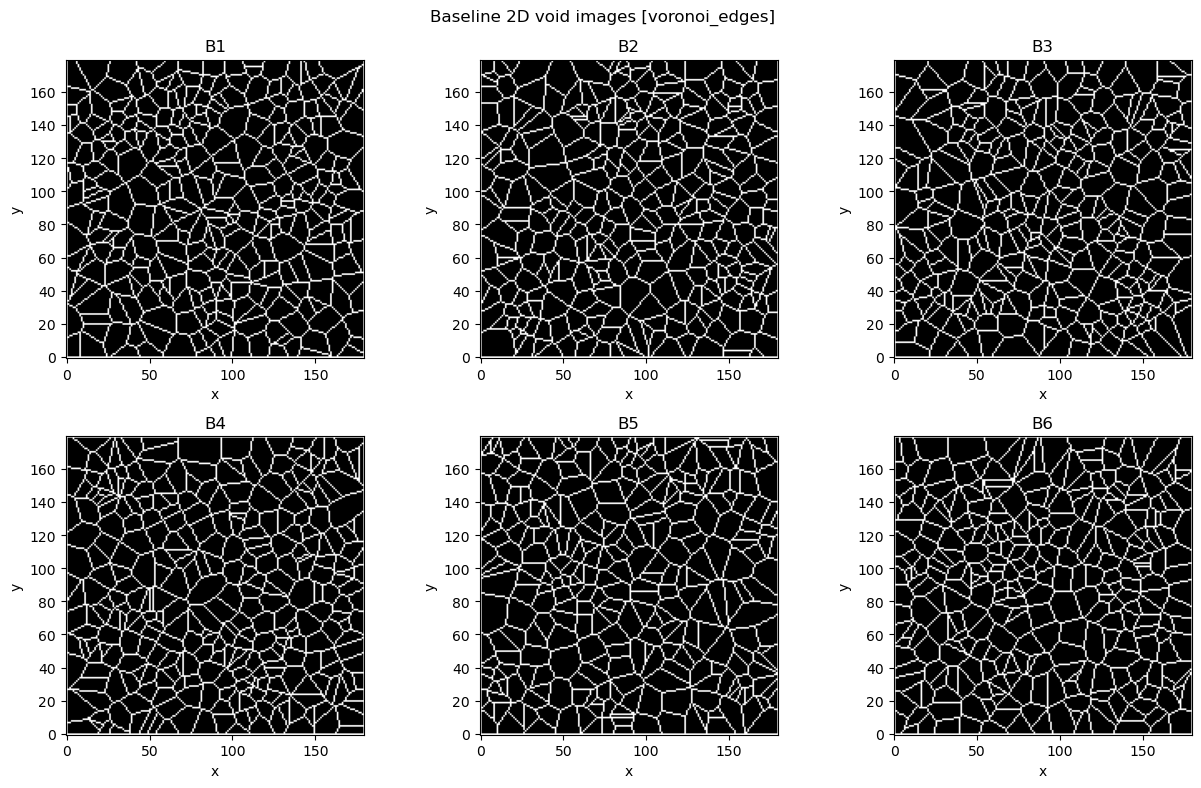

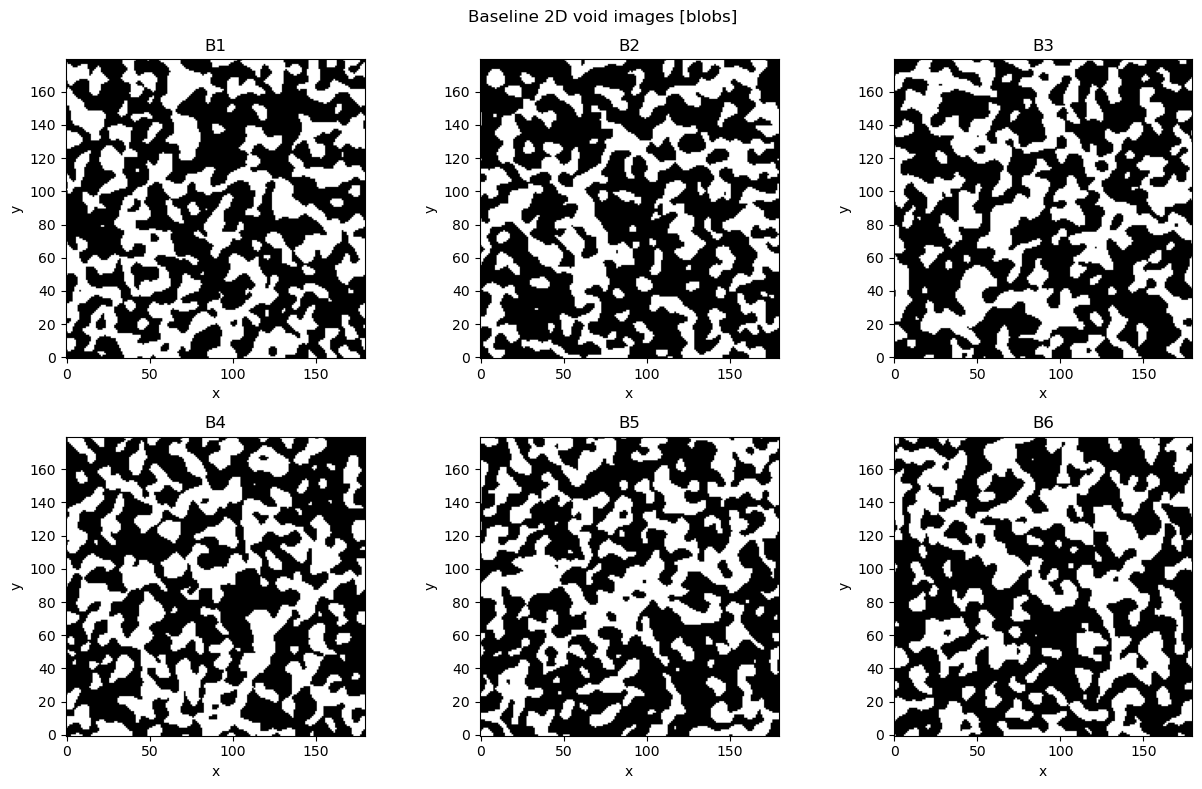

In [6]:
for generator_name in MATRIX_GENERATORS:
    baseline_images = baseline_images_by_generator[generator_name]
    ncols = min(3, N_BASELINES)
    nrows = (N_BASELINES + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(4.2 * ncols, 4.0 * nrows), squeeze=False
    )

    baseline_ids = sorted(baseline_images.keys())
    for idx, baseline_id in enumerate(baseline_ids):
        ax = axes[idx // ncols, idx % ncols]
        ax.imshow(baseline_images[baseline_id].T, origin="lower", cmap="gray")
        ax.set_title(f"B{baseline_id}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    for idx in range(len(baseline_ids), nrows * ncols):
        axes[idx // ncols, idx % ncols].axis("off")

    fig.suptitle(f"Baseline 2D void images [{generator_name}]")
    plt.tight_layout()
    plt.show()

## Run baseline + vug cases

In [7]:
all_results: list[dict[str, float | int | str]] = []
all_diagnostics: dict[str, dict[str, object]] = {}
case_void_images: dict[str, np.ndarray] = {}

for generator_index, generator_name in enumerate(MATRIX_GENERATORS, start=1):
    baseline_images = baseline_images_by_generator[generator_name]
    case_prefix = f"{generator_name}_" if len(MATRIX_GENERATORS) > 1 else ""

    for baseline_id in iter_progress(
        sorted(baseline_images.keys()),
        desc=f"Running 2D study [{generator_name}]",
        total=len(baseline_images),
        enabled=USE_TQDM,
        leave=True,
    ):
        baseline_void = baseline_images[baseline_id]

        baseline_case_name = f"{case_prefix}B{baseline_id}_baseline"
        case_void_images[baseline_case_name] = baseline_void.copy()
        base_row, base_diag = evaluate_case_2d(
            matrix_generator=generator_name,
            baseline_id=baseline_id,
            case_name=baseline_case_name,
            family="baseline",
            orientation="none",
            config_index=0,
            radii_vox=(0, 0),
            binary_void=baseline_void,
            baseline_void=baseline_void,
            case_seed=BASE_SEED + 9000 + 1000 * generator_index + baseline_id,
            baseline_kabs=None,
        )
        baseline_kabs = float(base_row["K_axis_m2"])
        all_results.append(base_row)
        all_diagnostics[baseline_case_name] = base_diag

        for j, tpl in iter_progress(
            list(enumerate(vug_templates, start=1)),
            desc=f"{generator_name} | B{baseline_id}: vug configs",
            total=len(vug_templates),
            enabled=USE_TQDM,
            leave=False,
        ):
            case_root = str(tpl["case"])
            family = str(tpl["family"])
            orientation = str(tpl["orientation"])
            config_index = int(tpl["config_index"])
            radii = tuple(int(v) for v in tuple(tpl["radii"]))

            case_name = f"{case_prefix}B{baseline_id}_{case_root}"
            if family == "circular":
                case_void, _ = insert_circular_vug_2d(
                    baseline_void, radius_vox=radii[0]
                )
            else:
                case_void, _ = insert_elliptical_vug_2d(baseline_void, radii_vox=radii)

            case_void_images[case_name] = case_void.copy()

            row, diag = evaluate_case_2d(
                matrix_generator=generator_name,
                baseline_id=baseline_id,
                case_name=case_name,
                family=family,
                orientation=orientation,
                config_index=config_index,
                radii_vox=radii,
                binary_void=case_void,
                baseline_void=baseline_void,
                case_seed=(
                    BASE_SEED
                    + 20000
                    + 100000 * generator_index
                    + 1000 * baseline_id
                    + j
                ),
                baseline_kabs=baseline_kabs,
            )
            all_results.append(row)
            all_diagnostics[case_name] = diag

print("total solved cases:", len(all_results))

Running 2D study [voronoi_edges]:   0%|                                                                                                      | 0/6 [00:00<?, ?it/s]OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.

voronoi_edges | B1: vug configs:   0%|                                                                                                      | 0/15 [00:00<?, ?it/s]
voronoi_edges | B1: vug configs:   7%|██████▎                                                                                       | 1/15 [00:00<00:03,  4.33it/s]
voronoi_edges | B1: vug configs:  13%|████████████▌                                                                                 | 2/15 [00:00<00:03,  4.26it/s]
voronoi_edges | B1: vug configs:  20%|██████████████████▊                                                                           | 3/15 [00:00<00:02,  4.21it/s]
voronoi_edges | B1: vug configs:  27%|█████████████████████████                    

total solved cases: 192


In [8]:
header = (
    f"{'generator':<14} {'case':<50} {'family':<10} {'orientation':<20} {'cfg':>3} "
    f"{'r_eq':>7} {'phi[%]':>8} {'K[m2]':>11} {'K/K0':>7} {'Np':>5} {'Nt':>6}"
)
print(header)
print("-" * len(header))
for row in all_results:
    print(
        f"{str(row['matrix_generator']):<14} {str(row['case']):<50} "
        f"{str(row['family']):<10} {str(row['orientation']):<20} "
        f"{int(row['config_index']):>3d} {float(row['equivalent_radius_vox']):>7.2f} "
        f"{100.0 * float(row['phi_image']):>8.3f} {float(row['K_axis_m2']):>11.3e} "
        f"{float(row['K_ratio_to_baseline']):>7.3f} {int(row['Np']):>5d} {int(row['Nt']):>6d}"
    )

generator      case                                               family     orientation          cfg    r_eq   phi[%]       K[m2]    K/K0    Np     Nt
-------------------------------------------------------------------------------------------------------------------------------------------------------
voronoi_edges  voronoi_edges_B1_baseline                          baseline   none                   0    0.00   17.981   3.553e-18   1.000    59     95
voronoi_edges  voronoi_edges_B1_circle_cfg1_r12                   circular   isotropic              1   12.00   19.028   4.009e-18   1.129    64    105
voronoi_edges  voronoi_edges_B1_circle_cfg2_r16                   circular   isotropic              2   16.00   19.932   3.413e-18   0.961    64    102
voronoi_edges  voronoi_edges_B1_circle_cfg3_r20                   circular   isotropic              3   20.00   21.157   4.092e-18   1.152    64    105
voronoi_edges  voronoi_edges_B1_circle_cfg4_r24                   circular   isotropic  

## Pre/Post vug images for baseline 1

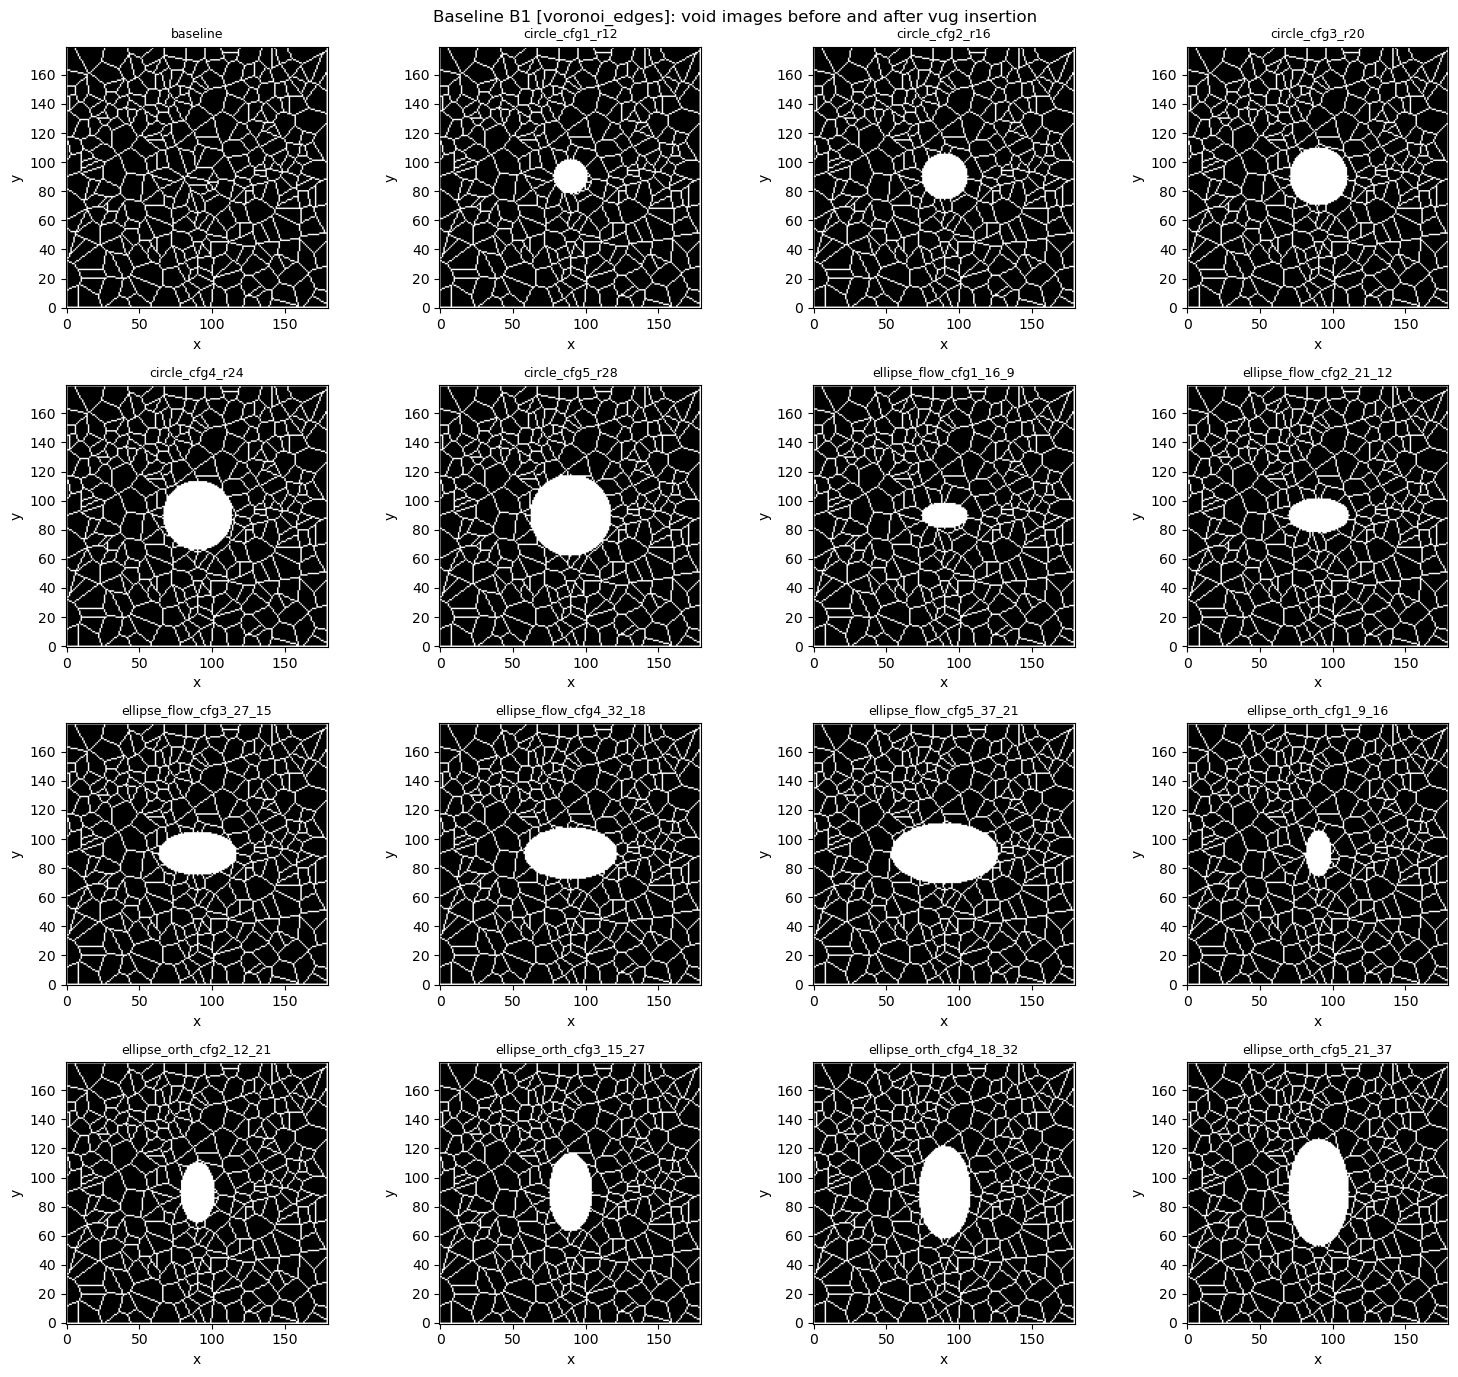

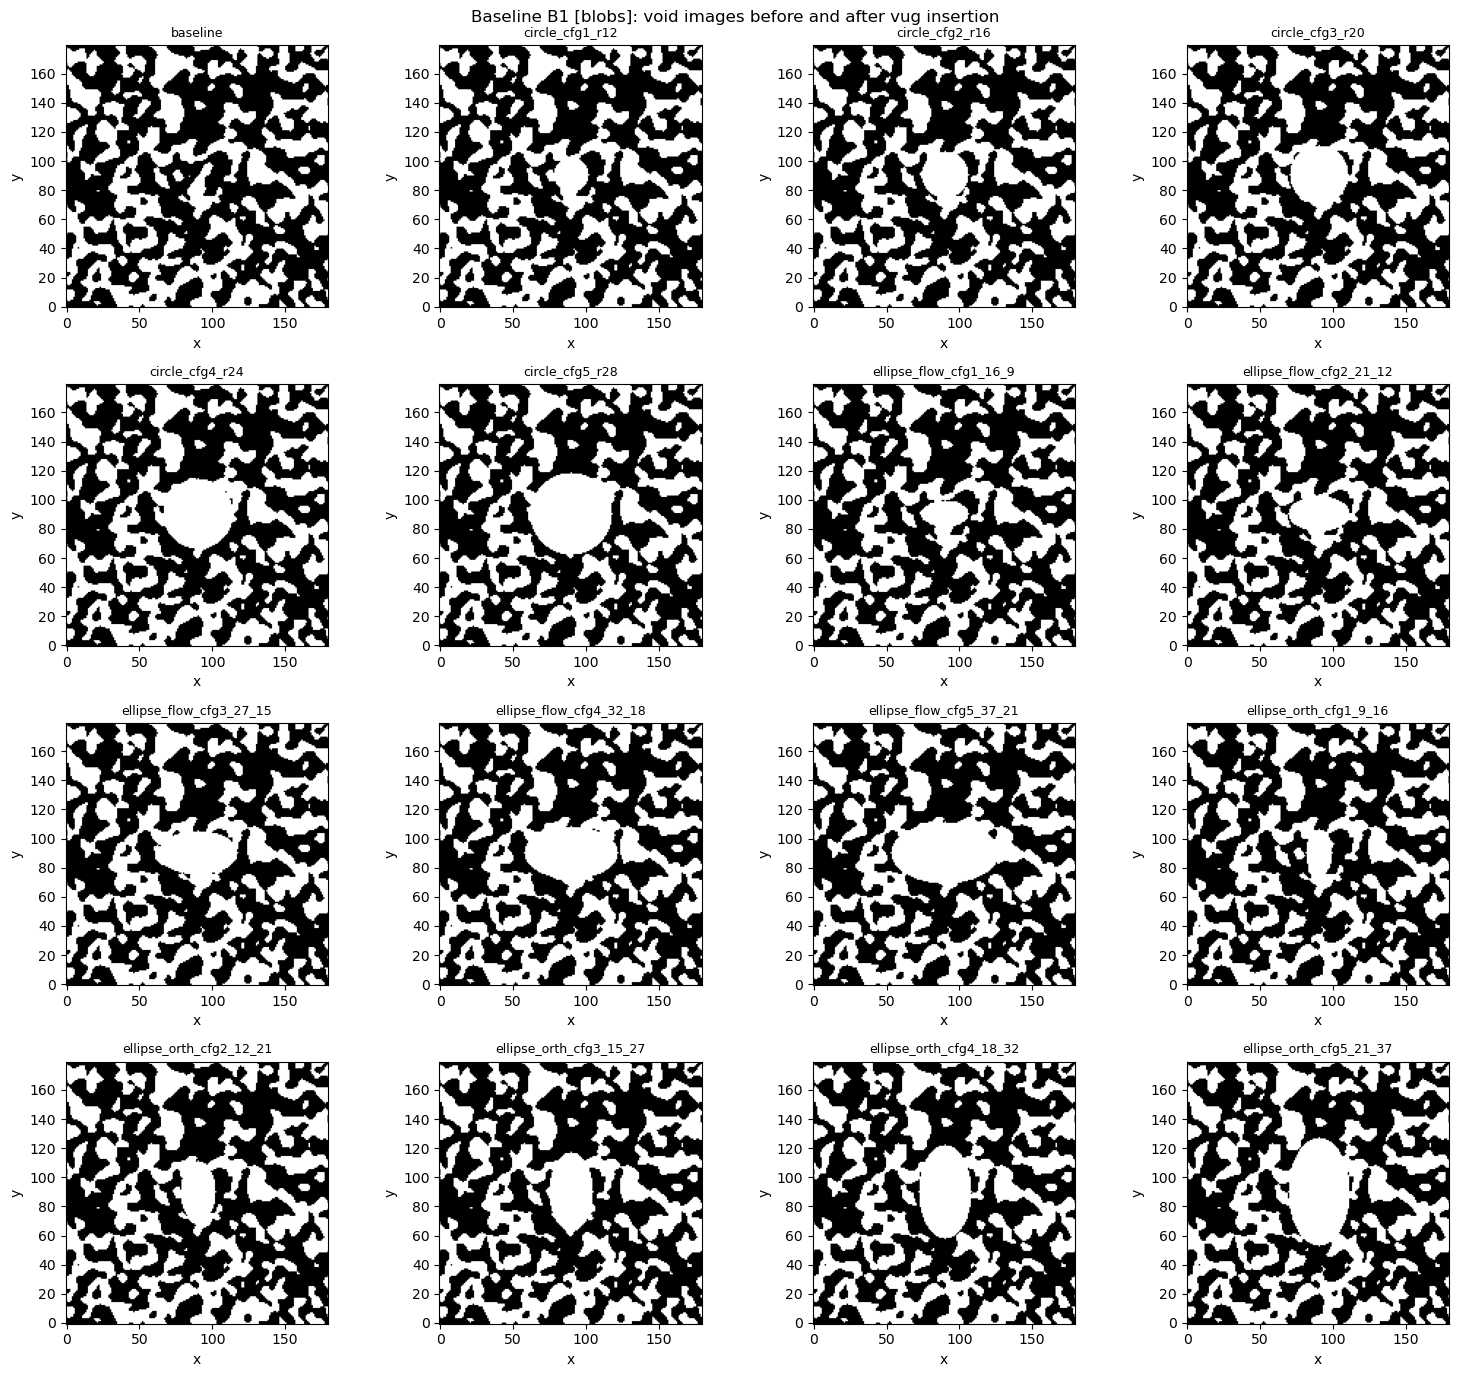

In [9]:
for generator_name in MATRIX_GENERATORS:
    case_prefix = f"{generator_name}_" if len(MATRIX_GENERATORS) > 1 else ""
    b1_cases = [f"{case_prefix}B1_baseline"] + [
        f"{case_prefix}B1_{tpl['case']}" for tpl in vug_templates
    ]
    b1_cases = [c for c in b1_cases if c in case_void_images]
    if not b1_cases:
        continue

    ncols = 4
    nrows = (len(b1_cases) + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(3.8 * ncols, 3.5 * nrows), squeeze=False
    )

    for idx, case_name in enumerate(b1_cases):
        ax = axes[idx // ncols, idx % ncols]
        ax.imshow(case_void_images[case_name].T, origin="lower", cmap="gray")
        title = case_name.replace(f"{case_prefix}B1_", "")
        ax.set_title(title, fontsize=9)
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    for idx in range(len(b1_cases), nrows * ncols):
        axes[idx // ncols, idx % ncols].axis("off")

    fig.suptitle(
        f"Baseline B1 [{generator_name}]: void images before and after vug insertion"
    )
    plt.tight_layout()
    plt.show()

## Aggregate response over baselines

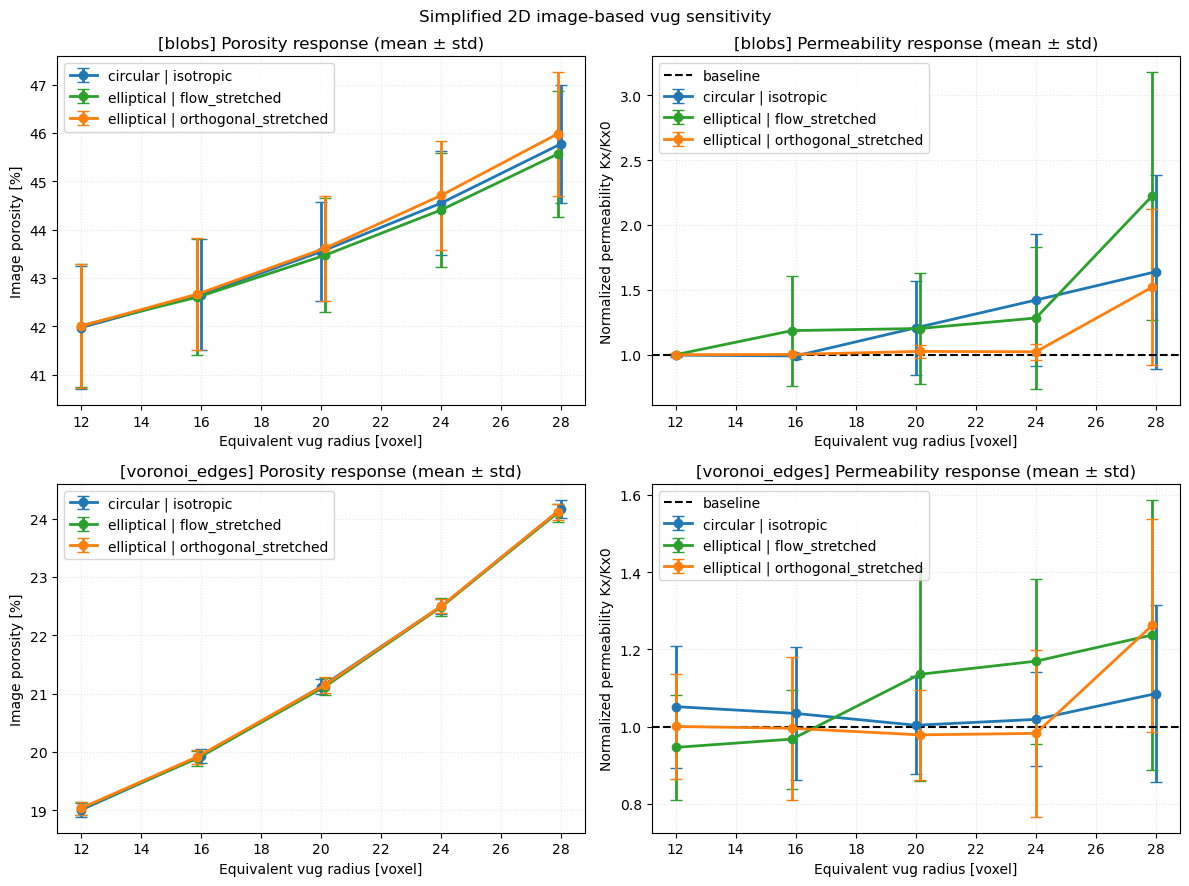

In [10]:
aggregated: dict[tuple[str, str, str, int], dict[str, object]] = {}
for row in all_results:
    if str(row["family"]) == "baseline":
        continue
    key = (
        str(row["matrix_generator"]),
        str(row["family"]),
        str(row["orientation"]),
        int(row["config_index"]),
    )
    if key not in aggregated:
        aggregated[key] = {
            "equivalent_radius_vox": float(row["equivalent_radius_vox"]),
            "k_ratio": [],
            "phi_image": [],
        }
    aggregated[key]["k_ratio"].append(float(row["K_ratio_to_baseline"]))
    aggregated[key]["phi_image"].append(float(row["phi_image"]))

orientation_groups = [
    ("circular", "isotropic", "tab:blue"),
    ("elliptical", "flow_stretched", "tab:green"),
    ("elliptical", "orthogonal_stretched", "tab:orange"),
]

generators_in_results = sorted({k[0] for k in aggregated})
fig, axes = plt.subplots(
    len(generators_in_results),
    2,
    figsize=(12, 4.5 * max(1, len(generators_in_results))),
    squeeze=False,
)
for row_idx, generator_name in enumerate(generators_in_results):
    ax_phi = axes[row_idx, 0]
    ax_k = axes[row_idx, 1]
    for family, orientation, color in orientation_groups:
        keys = sorted(
            [
                k
                for k in aggregated
                if k[0] == generator_name and k[1] == family and k[2] == orientation
            ],
            key=lambda k: k[3],
        )
        if not keys:
            continue

        r_eq = np.array(
            [aggregated[k]["equivalent_radius_vox"] for k in keys], dtype=float
        )
        k_mean = np.array(
            [np.mean(aggregated[k]["k_ratio"]) for k in keys], dtype=float
        )
        k_std = np.array([np.std(aggregated[k]["k_ratio"]) for k in keys], dtype=float)
        phi_mean = 100.0 * np.array(
            [np.mean(aggregated[k]["phi_image"]) for k in keys], dtype=float
        )
        phi_std = 100.0 * np.array(
            [np.std(aggregated[k]["phi_image"]) for k in keys], dtype=float
        )

        label = f"{family} | {orientation}"
        ax_phi.errorbar(
            r_eq,
            phi_mean,
            yerr=phi_std,
            marker="o",
            linewidth=2,
            capsize=4,
            color=color,
            label=label,
        )
        ax_k.errorbar(
            r_eq,
            k_mean,
            yerr=k_std,
            marker="o",
            linewidth=2,
            capsize=4,
            color=color,
            label=label,
        )

    ax_phi.set_xlabel("Equivalent vug radius [voxel]")
    ax_phi.set_ylabel("Image porosity [%]")
    ax_phi.set_title(f"[{generator_name}] Porosity response (mean ± std)")
    ax_phi.grid(alpha=0.3, linestyle=":")
    ax_phi.legend()

    ax_k.axhline(1.0, color="black", linestyle="--", linewidth=1.5, label="baseline")
    ax_k.set_xlabel("Equivalent vug radius [voxel]")
    ax_k.set_ylabel(f"Normalized permeability K{FLOW_AXIS}/K{FLOW_AXIS}0")
    ax_k.set_title(f"[{generator_name}] Permeability response (mean ± std)")
    ax_k.grid(alpha=0.3, linestyle=":")
    ax_k.legend()

fig.suptitle("Simplified 2D image-based vug sensitivity")
plt.tight_layout()
plt.show()

## K/K0 frequency distributions by equivalent radius

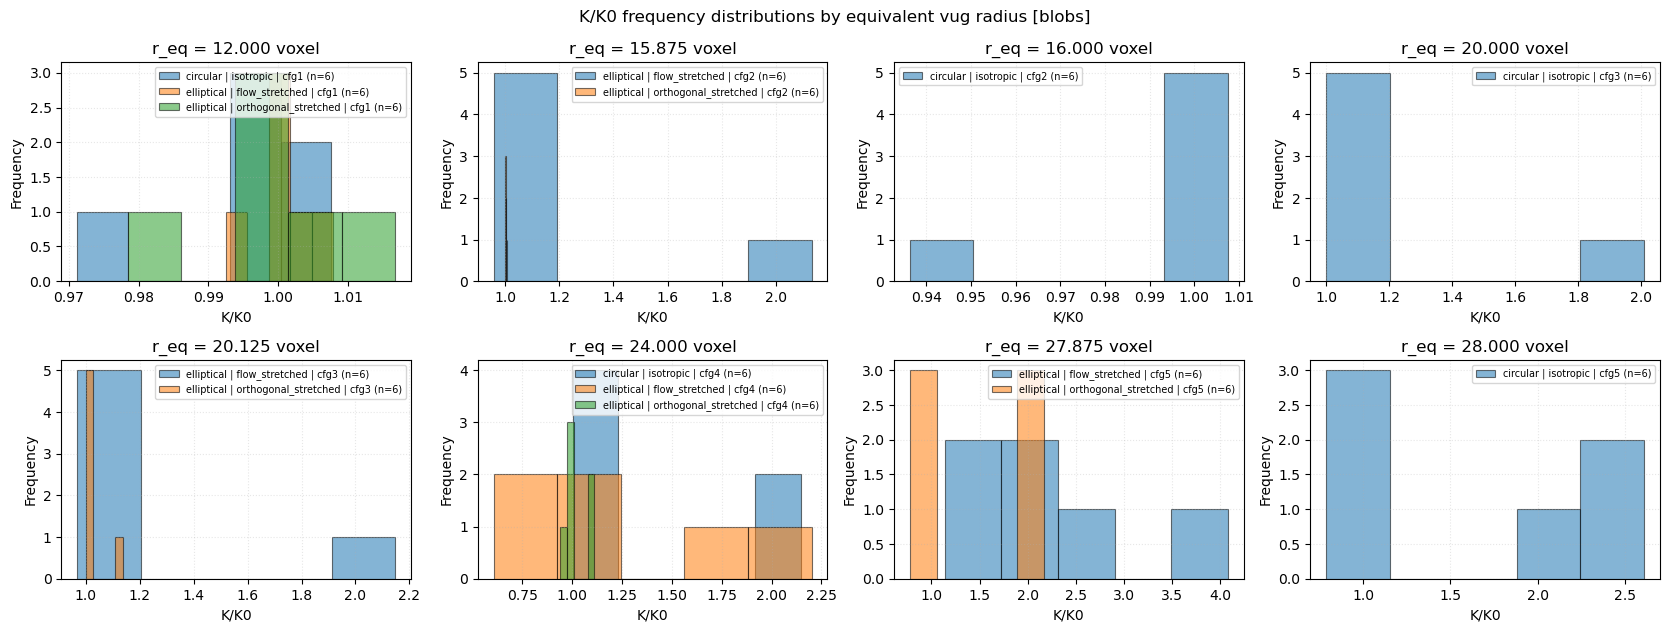

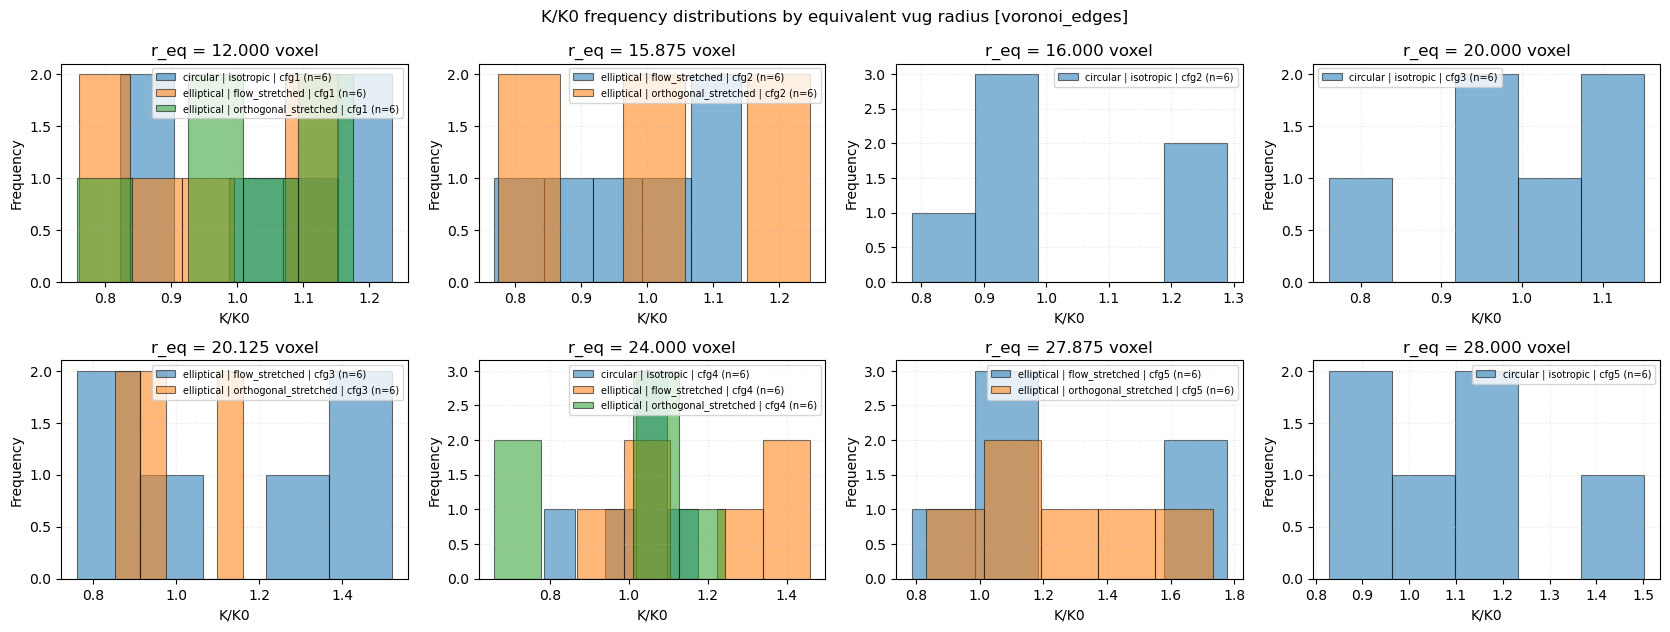

In [11]:
for generator_name in sorted(
    {
        str(row["matrix_generator"])
        for row in all_results
        if str(row["family"]) != "baseline"
    }
):
    kk0_by_radius_and_config: dict[float, dict[str, list[float]]] = {}
    for row in all_results:
        if str(row["family"]) == "baseline":
            continue
        if str(row["matrix_generator"]) != generator_name:
            continue

        radius_key = round(float(row["equivalent_radius_vox"]), 3)
        cfg_label = (
            f"{row['family']} | {row['orientation']} | cfg{int(row['config_index'])}"
        )

        if radius_key not in kk0_by_radius_and_config:
            kk0_by_radius_and_config[radius_key] = {}
        if cfg_label not in kk0_by_radius_and_config[radius_key]:
            kk0_by_radius_and_config[radius_key][cfg_label] = []
        kk0_by_radius_and_config[radius_key][cfg_label].append(
            float(row["K_ratio_to_baseline"])
        )

    radius_keys = sorted(kk0_by_radius_and_config.keys())
    ncols_hist = min(4, max(1, len(radius_keys)))
    nrows_hist = (len(radius_keys) + ncols_hist - 1) // ncols_hist
    fig, axes = plt.subplots(
        nrows_hist,
        ncols_hist,
        figsize=(4.2 * ncols_hist, 3.2 * nrows_hist),
        squeeze=False,
    )

    for ax, radius_key in zip(axes.flat, radius_keys):
        cfg_map = kk0_by_radius_and_config[radius_key]
        for cfg_label, values in sorted(cfg_map.items()):
            vals = np.asarray(values, dtype=float)
            if vals.size == 0:
                continue
            bins = np.histogram_bin_edges(vals, bins=min(10, max(5, vals.size // 2)))
            if np.unique(bins).size < 2:
                center = float(vals.mean())
                bins = np.array([center - 0.03, center + 0.03], dtype=float)

            ax.hist(
                vals,
                bins=bins,
                alpha=0.55,
                edgecolor="black",
                linewidth=0.8,
                label=f"{cfg_label} (n={vals.size})",
            )

        ax.set_title(f"r_eq = {radius_key:.3f} voxel")
        ax.set_xlabel("K/K0")
        ax.set_ylabel("Frequency")
        ax.grid(alpha=0.3, linestyle=":")
        ax.legend(fontsize=7)

    for ax in axes.flat[len(radius_keys) :]:
        ax.axis("off")

    fig.suptitle(
        f"K/K0 frequency distributions by equivalent vug radius [{generator_name}]"
    )
    plt.tight_layout()
    plt.show()

## Export Plotly pore-network visualizations

In [12]:
print("total plotly figures:", len(all_diagnostics))
notebooks_env = os.environ.get("VOIDS_NOTEBOOKS_PATH")
if notebooks_env:
    notebooks_base = Path(notebooks_env).expanduser()
else:
    cwd = Path.cwd().resolve()
    repo_root = None
    for candidate in (cwd, *cwd.parents):
        if (candidate / "pixi.toml").exists() and (
            candidate / "src" / "voids"
        ).exists():
            repo_root = candidate
            break
    notebooks_base = (repo_root / "notebooks") if repo_root is not None else cwd

plotly_export_root = notebooks_base / "outputs/09_mwe_image_based_vug_sensitivity_2d"
plotly_html_dir = plotly_export_root / "plotly_html"
plotly_png_dir = plotly_export_root / "plotly_png"
plotly_html_dir.mkdir(parents=True, exist_ok=True)
plotly_png_dir.mkdir(parents=True, exist_ok=True)

print("plotly html dir:", plotly_html_dir)
print("plotly png dir:", plotly_png_dir)

png_export_summary = {"plotly_kaleido": 0, "matplotlib_fallback": 0, "failed": 0}
for case_name in iter_progress(
    sorted(all_diagnostics.keys()),
    desc="Exporting plotly figures",
    total=len(all_diagnostics),
    enabled=USE_TQDM,
    leave=True,
):
    fig = all_diagnostics[case_name]["plotly"]
    html_path = plotly_html_dir / f"{case_name}.html"
    png_path = plotly_png_dir / f"{case_name}.png"

    fig.write_html(html_path, include_plotlyjs="cdn")
    try:
        fig.write_image(png_path, format="png", scale=2)
        png_export_summary["plotly_kaleido"] += 1
    except Exception:
        try:
            save_network_png_matplotlib_2d(
                net=all_diagnostics[case_name]["net"],
                pore_pressure=np.asarray(
                    all_diagnostics[case_name]["pore_pressure"], dtype=float
                ),
                png_path=png_path,
                title=str(all_diagnostics[case_name]["plotly_title"]),
                max_throats=PLOTLY_MAX_THROATS,
            )
            png_export_summary["matplotlib_fallback"] += 1
        except Exception as exc2:
            png_export_summary["failed"] += 1
            print(f"failed to save PNG for {case_name}: {exc2}")

print("png export summary:", png_export_summary)

total plotly figures: 192
plotly html dir: /Users/dtvolpatto/Work/voids/notebooks/outputs/09_mwe_image_based_vug_sensitivity_2d/plotly_html
plotly png dir: /Users/dtvolpatto/Work/voids/notebooks/outputs/09_mwe_image_based_vug_sensitivity_2d/plotly_png


Exporting plotly figures: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:20<00:00,  9.54it/s]

png export summary: {'plotly_kaleido': 0, 'matplotlib_fallback': 192, 'failed': 0}


## Interpretation and limitations

Typical behavior to verify in your run:

- vug insertion increases porosity across baselines.
- `K/K0` varies with both vug size and orientation, not only with added void area.
- dispersion across baselines quantifies sensitivity to matrix realization.

Main limitations:

- single centered vug per case (no random vug placement ensemble).
- synthetic grayscale model is simplified.
- 2D study is best used for trend exploration before 3D confirmation.
